# Система Рекомендаций Книг на Основе Датасета GoodBooks-10k

## Введение

**Этот учебный проект реализует прототип книжного рекомендательного сервиса с использованием датасета Goodbooks-10k, включающего отзывы пользователей, информацию о книгах и теги. В рамках проекта будет использован структурированный подход: от подготовке данных и EDA до реализации моделей (неперсонализированные, контентные, коллаборативная фильтрация и матричное разложение), их оценки и предложений по улучшению.** 

**Цель** — создать рабочий прототип, который демонстрирует сравнение методов и их адаптацию к проблемам, таким как разреженность данных, смещение популярности и холодный старт.

### Этапы Реализации

- **1: Знакомство с Данными и EDA (Exploratory Data Analysis)**
  
- **2: Базовые и Контентные Модели**

  
- **3: Коллаборативная Фильтрация (Collaborative Filtering — CF)**

- **4: Матричные Разложения (Matrix Factorization)**

- **5: Оценка и Сравнение Моделей**

- **6: Гибридизация и Выводы**

# Система Рекомендаций Книг на Основе Датасета GoodBooks-10k

## Введение

**Этот учебный проект реализует прототип книжного рекомендательного сервиса с использованием датасета Goodbooks-10k, включающего отзывы пользователей, информацию о книгах и теги. В рамках проекта будет использован структурированный подход: от подготовке данных и EDA до реализации моделей (неперсонализированные, контентные, коллаборативная фильтрация и матричное разложение), их оценки и предложений по улучшению.** 

**Цель** — создать рабочий прототип, который демонстрирует сравнение методов и их адаптацию к проблемам, таким как разреженность данных, смещение популярности и холодный старт.

### Этапы Реализации

- **1. Знакомство с Данными и EDA (Exploratory Data Analysis)**
  
- **2. Базовые и Контентные Модели**

  
- **3. Коллаборативная Фильтрация (Collaborative Filtering — CF)**

- **4. Матричные Разложения (Matrix Factorization)**

- **5. Оценка и Сравнение Моделей**

- **6. Гибридизация и Выводы**

## Импортируем необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
import re
import itertools
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## 1. Загрузка и исследовательский анализ данных (EDA)

In [3]:
# Импорт таблиц
user_reviews = pd.read_csv('ratings.csv')
literature = pd.read_csv('books.csv')
keywords = pd.read_csv('tags.csv')
literature_keywords = pd.read_csv('book_tags.csv')

In [4]:
# Разведочный анализ отзывов
user_reviews.head()

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


In [5]:
user_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981756 entries, 0 to 981755
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   book_id  981756 non-null  int64
 1   user_id  981756 non-null  int64
 2   rating   981756 non-null  int64
dtypes: int64(3)
memory usage: 22.5 MB


In [6]:
user_reviews.describe()

,book_id,user_id,rating
count,981756.000000,981756.000000,981756.000000
mean,4943.275636,25616.759933,3.856534
std,2873.207415,15228.338826,0.983941
min,1.000000,1.000000,1.000000
25%,2457.000000,12372.000000,3.000000
50%,4921.000000,25077.000000,4.000000
75%,7414.000000,38572.000000,5.000000
max,10000.000000,53424.000000,5.000000


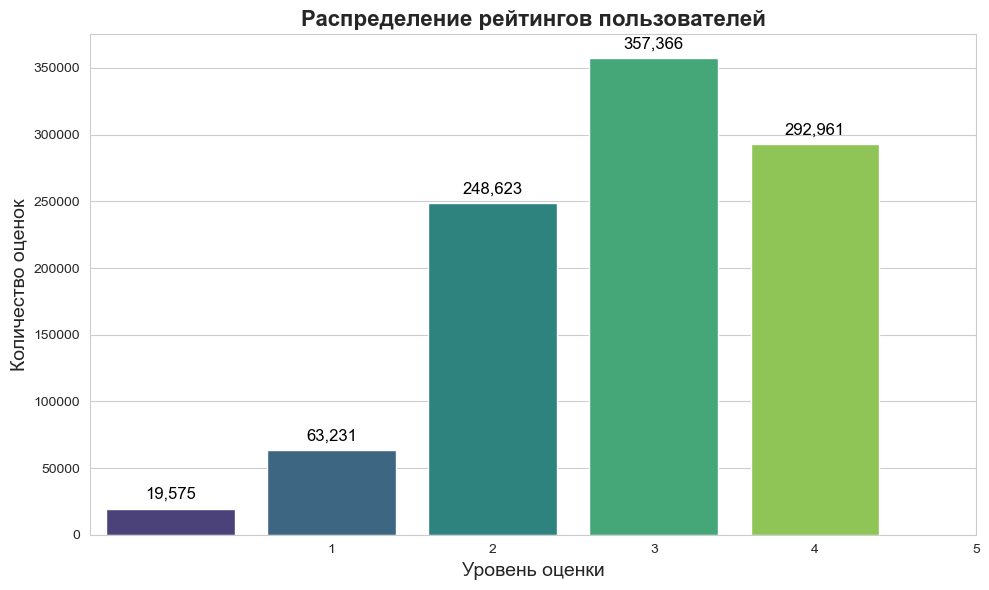

In [7]:
# Визуализация частоты оценок
sns.set_style("whitegrid")

# Создаем фигуру
plt.figure(figsize=(10, 6))

# Строим улучшенную countplot с кастомной палитрой
palette = sns.color_palette("viridis", len(user_reviews['rating'].unique()))
ax = sns.countplot(
    x='rating',
    hue='rating',  # Присваиваем x к hue для совместимости с будущими версиями Seaborn
    data=user_reviews,
    order=sorted(user_reviews['rating'].unique()),
    palette=palette,
    legend=False  # Убираем легенду, так как она не требуется для этого графика
)

# Добавляем заголовок и подписи осей
ax.set_title('Распределение рейтингов пользователей', fontsize=16, fontweight='bold')
ax.set_xlabel('Уровень оценки', fontsize=14)
ax.set_ylabel('Количество оценок', fontsize=14)

# Добавляем аннотации с подсчетом на каждом баре для лучшей читаемости
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',  # Форматируем число с разделителями
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12,
        color='black',
        xytext=(0, 5),  # Смещение текста вверх
        textcoords='offset points'
    )

# Улучшаем разделители осей: четкие целые числа для рейтингов
ax.set_xticks(sorted(user_reviews['rating'].unique()))
ax.set_xticklabels(sorted(user_reviews['rating'].unique()))

# Показываем график
plt.tight_layout()  # Автоматически подгоняем layout
plt.show()

***Распределение показывает что большинство пользователей довольны***

In [8]:
# Разведочный анализ литературы
literature.head()

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m/2767052.jpg,https://images.gr-assets.com/books/1447303603s/2767052.jpg
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)",eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m/3.jpg,https://images.gr-assets.com/books/1474154022s/3.jpg
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m/41865.jpg,https://images.gr-assets.com/books/1361039443s/41865.jpg
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m/2657.jpg,https://images.gr-assets.com/books/1361975680s/2657.jpg
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m/4671.jpg,https://images.gr-assets.com/books/1490528560s/4671.jpg


*Напишем функцию для анализа данных по литературе*

In [9]:
def infoOut(df, details=False, missing_values=False):
    """
    Функция для получения информации о DataFrame.

    Args:
        df (pd.DataFrame): DataFrame для анализа.
        details (bool): Если True, возвращает расширенную информацию.
        missing_values (bool): Если True, возвращает информацию о пропущенных значениях.

    Returns:
        pd.DataFrame: DataFrame с информацией о столбцах.
    """
    dfInfo = df.columns.to_frame(name='Column')
    dfInfo['Missing Values'] = df.isnull().sum()
    dfInfo['%'] = round(df.isnull().sum() / len(df) * 100, 2)
    dfInfo['Dtype'] = df.dtypes

    # Подсчитываем общее количество дубликатов в dfFrame
    dfInfo['Duplicates'] = df.duplicated().sum()
    dfInfo['Unique Values'] = df.nunique()
    dfInfo['Total Rows'] = len(df)

    # Нормализуем данные: приводим к нижнему регистру и убираем пробелы
    df_normalized = df.astype(str).apply(lambda x: x.str.lower().str.strip())

    # Группируем по всем столбцам и считаем неявные дубликаты
    implicit_duplicates = df_normalized.groupby(list(df_normalized.columns)).size()

    # Записываем количество неявных дубликатов в dfInfo
    dfInfo['Implicit Duplicates'] = (implicit_duplicates > 1).sum()

    # Примерные значения для каждой колонки
    dfInfo['Example Values'] = df.apply(lambda x: ', '.join(map(str, x.unique()[:3].tolist())), axis=0)

    # Проверяем наличие дубликатов по выбранным столбцам, если их больше одного
    if df.shape[1] > 1:
        sample_columns = df.columns[1:3] # Выбираем первые два столбца для проверки
        dfInfo['Duplicates by Sample Columns'] = df.duplicated(subset=sample_columns).sum()
    else:
        dfInfo['Duplicates by Sample Columns'] = 0 # Если столбцов меньше двух, записываем 0

    dfInfo.reset_index(drop=True, inplace=True)

    if details:
        rangeIndex = df.index
        totalColumns = dfInfo['Column'].count()
        dtypesCount = dfInfo['Dtype'].value_counts()
        totalMemory = df.memory_usage().sum()
        if missing_values:
            return dfInfo, rangeIndex, totalColumns, dtypesCount, totalMemory, df.isnull().sum(), dfInfo['Duplicates']
        else:
            return dfInfo, rangeIndex, totalColumns, dtypesCount, totalMemory
    else:
        return dfInfo

In [10]:
# Выведем аналитическую табличку
# Анализируем literature
train_info = infoOut(literature, details=True, missing_values=True)
trainInfo = train_info[0]
train_totalColumns = train_info[2]
train_totalMemory = train_info[4]

# Добавляем индикатор дубликатов для каждой строки в dfFrame
trainInfo['Duplicate Rows'] = literature.duplicated()

display(trainInfo)
display(f"Total Columns: {train_totalColumns}")
print(f"Memory Usage: {train_totalMemory} bytes")

,Column,Missing Values,%,Dtype,Duplicates,Unique Values,Total Rows,Implicit Duplicates,Example Values,Duplicates by Sample Columns,Duplicate Rows
0,id,0,0.00,int64,0,10000,10000,0,"1, 2, 3",0,False
1,book_id,0,0.00,int64,0,10000,10000,0,"2767052, 3, 41865",0,False
2,best_book_id,0,0.00,int64,0,10000,10000,0,"2767052, 3, 41865",0,False
3,work_id,0,0.00,int64,0,10000,10000,0,"2792775, 4640799, 3212258",0,False
4,books_count,0,0.00,int64,0,597,10000,0,"272, 491, 226",0,False
5,isbn,700,7.00,object,0,9300,10000,0,"439023483, 439554934, 316015849",0,False
6,isbn13,585,5.85,float64,0,9153,10000,0,"9780439023480.0, 9780439554930.0, 9780316015840.0",0,False
7,authors,0,0.00,object,0,4664,10000,0,"Suzanne Collins, J.K. Rowling, Mary GrandPré, Stephenie Meyer",0,False
8,original_publication_year,21,0.21,float64,0,293,10000,0,"2008.0, 1997.0, 2005.0",0,False
9,original_title,585,5.85,object,0,9274,10000,0,"The Hunger Games, Harry Potter and the Philosopher's Stone, Twilight",0,False


'Total Columns: 23'

Memory Usage: 1840132 bytes


**Датасет без дубликатов и с низкими пропусками. Уникальность высокая. Также, стоит отметить одинаковое количество строк с user_reviews (по 10 000), что обеспечивает полные связи.**

In [11]:
# Заменим пустые значения
literature['original_title'] = literature['original_title'].fillna(literature['title'])

# Посмотрим статистику по числовым столбцам
numeric_columns = literature.select_dtypes(include=['float64', 'int64']).columns

print("Статистика для literature:\n")
display(literature[numeric_columns].describe())

Статистика для literature:



,id,book_id,best_book_id,work_id,books_count,isbn13,original_publication_year,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
count,10000.00000,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,9.415000e+03,9979.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04
mean,5000.50000,5.264697e+06,5.471214e+06,8.646183e+06,75.712700,9.755044e+12,1981.987674,4.002191,5.400124e+04,5.968732e+04,2919.955300,1345.040600,3110.885000,11475.893800,1.996570e+04,2.378981e+04
std,2886.89568,7.575462e+06,7.827330e+06,1.175106e+07,170.470728,4.428619e+11,152.576665,0.254427,1.573700e+05,1.678038e+05,6124.378132,6635.626263,9717.123578,28546.449183,5.144736e+04,7.976889e+04
min,1.00000,1.000000e+00,1.000000e+00,8.700000e+01,1.000000,1.951703e+08,-1750.000000,2.470000,2.716000e+03,5.510000e+03,3.000000,11.000000,30.000000,323.000000,7.500000e+02,7.540000e+02
25%,2500.75000,4.627575e+04,4.791175e+04,1.008841e+06,23.000000,9.780316e+12,1990.000000,3.850000,1.356875e+04,1.543875e+04,694.000000,196.000000,656.000000,3112.000000,5.405750e+03,5.334000e+03
50%,5000.50000,3.949655e+05,4.251235e+05,2.719524e+06,40.000000,9.780452e+12,2004.000000,4.020000,2.115550e+04,2.383250e+04,1402.000000,391.000000,1163.000000,4894.000000,8.269500e+03,8.836000e+03
75%,7500.25000,9.382225e+06,9.636112e+06,1.451775e+07,67.000000,9.780831e+12,2011.000000,4.180000,4.105350e+04,4.591500e+04,2744.250000,885.000000,2353.250000,9287.000000,1.602350e+04,1.730450e+04
max,10000.00000,3.328864e+07,3.553423e+07,5.639960e+07,3455.000000,9.790008e+12,2017.000000,4.820000,4.780653e+06,4.942365e+06,155254.000000,456191.000000,436802.000000,793319.000000,1.481305e+06,3.011543e+06


**Фокус на колонках: book_id, goodreads_book_id, authors, title — они выглядят корректно**

In [12]:
# Разведочный анализ тегов
# Выведем аналитическую табличку
train_info = infoOut(literature_keywords, details=True, missing_values=True)
trainInfo = train_info[0]
train_totalColumns = train_info[2]
train_totalMemory = train_info[4]

# Добавляем индикатор дубликатов для каждой строки в dfFrame
trainInfo['Duplicate Rows'] = literature_keywords.duplicated()

display(trainInfo)
display(f"Total Columns: {train_totalColumns}")
print(f"Memory Usage: {train_totalMemory} bytes")

,Column,Missing Values,%,Dtype,Duplicates,Unique Values,Total Rows,Implicit Duplicates,Example Values,Duplicates by Sample Columns,Duplicate Rows
0,goodreads_book_id,0,0.0,int64,6,10000,999912,6,"1, 2, 3",757903,False
1,tag_id,0,0.0,int64,6,34252,999912,6,"30574, 11305, 11557",757903,False
2,count,0,0.0,int64,6,9401,999912,6,"167697, 37174, 34173",757903,False


'Total Columns: 3'

Memory Usage: 23998020 bytes


**Данные практически без пропусков и с высокой уникальностью, что указывает на их высокое качество. Кроме того, goodreads_book_id и id обеспечивают идеальное 1:1 совпадение для join.** 

In [13]:
# Проверка соответствия идентификаторов для связей
# Определение списка проверок с кортежами: (метка, колонка1, колонка2)
checks = [
    ('Общих book_id', user_reviews['book_id'], literature['id']),
    ('Общих goodreads_book_id', literature_keywords['goodreads_book_id'], literature['book_id']),
    ('Общих tag_id', literature_keywords['tag_id'], keywords['tag_id'])
]

# Цикл для выполнения проверок
for label, col1, col2 in checks:
    # Вычисление количества общих уникальных значений (пересечение множеств)
    common_count = len(set(col1) & set(col2))
    print(f'{label}: {common_count}')


Общих book_id: 10000
Общих goodreads_book_id: 10000
Общих tag_id: 34252


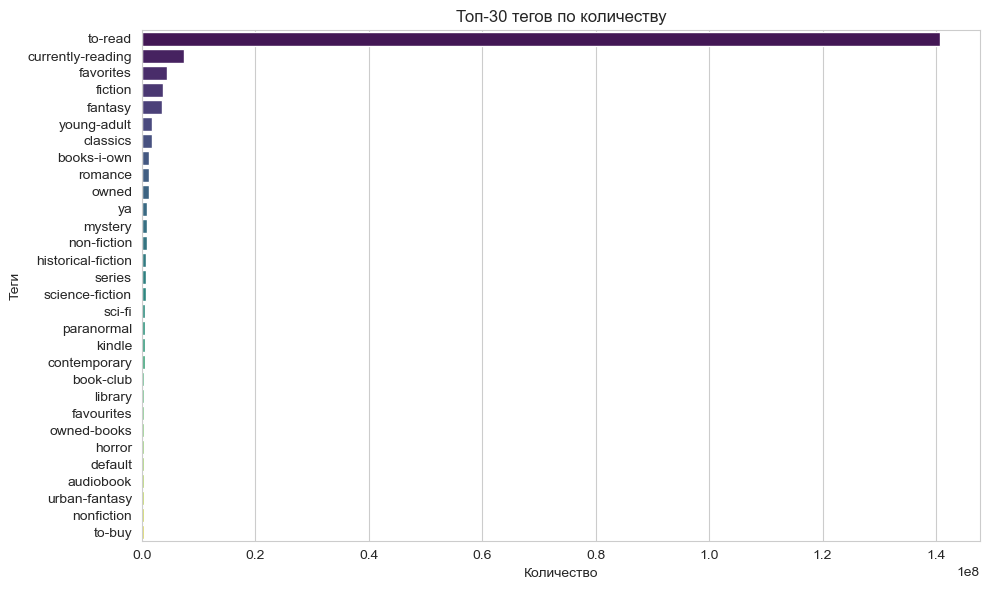

In [18]:
book_tag_counts = literature_keywords.merge(keywords, on='tag_id', how='inner')
tag_freq = book_tag_counts.groupby('tag_name')['count'].sum().reset_index().sort_values('count', ascending=False)
most_common_tags = tag_freq.head(30)

# Стиль и настройки графика для красоты
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Палитра для разнообразия цветов
palette = sns.color_palette("viridis", len(most_common_tags))

# Строим барплот, исправляя FutureWarning: назначаем hue на y-переменную (tag_name) и ставим legend=False
ax = sns.barplot(
    y='tag_name',  # Названия тегов по Y
    x='count',     # Частоты по X
    data=most_common_tags,
    palette=palette,
    hue='tag_name',  # Назначаем hue на tag_name для использования palette без предупреждений
    legend=False    # Отключаем легенду
)

plt.title('Топ-30 тегов по количеству')
plt.xlabel('Количество')
plt.ylabel('Теги')

plt.tight_layout()
plt.show()

**Видим что некоторые теги бессмысленны (например to-read и to-buy), что ухудшит модель сходства на основе TF-IDF**

In [19]:
### Фильтрация бесполезных тегов
keywords['tag_name'] = keywords['tag_name'].astype(str).str.lower().str.strip()

# Определение списка бесполезных паттернов
exclude_patterns = ['owned', 'favorites', 'currently-reading', 'series', 'books-i-own', 'to-', 'default', 'ebook', 'audiobook', 'audio', 'library', 'book-club', 'favourites']

# Создание регулярного выражения из списка паттернов (поиск любого из них с помощью |)
exclude_regex = '|'.join(exclude_patterns)

# Фильтрация DataFrame: удаление строк, где 'tag_name' содержит любой из бесполезных паттернов
keywords = keywords[~keywords['tag_name'].str.contains(exclude_regex, na=False)]

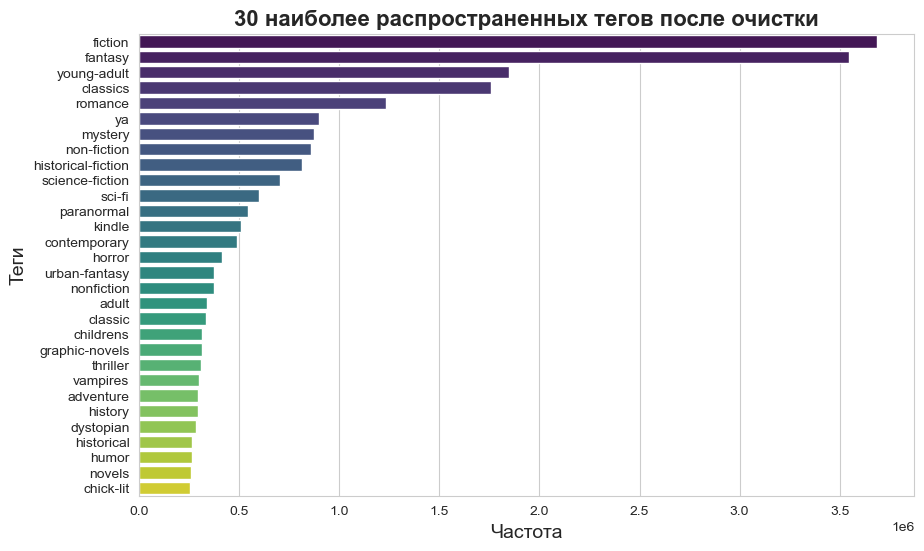

In [20]:
keyword_frequencies = literature_keywords.merge(keywords, on='tag_id', how='inner')
tag_popularity = keyword_frequencies.groupby('tag_name')['count'].sum().reset_index().sort_values('count', ascending=False)
top_tags = tag_popularity.head(30)

# Визуализация популярности топ-30 тегов
sns.set_style("whitegrid")

# Создаем фигуру
plt.figure(figsize=(10, 6))

palette = sns.color_palette("viridis", len(top_tags))
ax = sns.barplot(
    y='tag_name',
    x='count',
    data=top_tags,
    hue='tag_name', 
    palette=palette,
    legend=False  
)

# Добавляем заголовок и подписи осей
ax.set_title('30 наиболее распространенных тегов после очистки', fontsize=16, fontweight='bold')
ax.set_xlabel('Частота', fontsize=14)
ax.set_ylabel('Теги', fontsize=14)

plt.show()

In [21]:
### Дополнительная очистка: удаление тегов с цифрами и спецсимволами, сохранение топ-10000
keywords['tag_name'] = keywords['tag_name'].astype(str).str.lower().str.strip()

keywords = keywords[~keywords['tag_name'].str.contains(r'[0-9+()\[\]\\?/_. ,=]')]

keywords = keywords[keywords['tag_name'].str.match(r'^[a-zA-Z\s\-]+$')]

keywords = keywords[~keywords['tag_name'].str.match(r'^[-]')]

keywords = keywords[~keywords['tag_name'].str.match(r'[-]$')]

tag_popularity_all = literature_keywords.merge(keywords, on='tag_id', how='inner').groupby('tag_name')['count'].sum().reset_index().sort_values('count', ascending=False)
top_10000_tags = tag_popularity_all['tag_name'].head(10000)

# Фильтруем keywords, оставляя только теги из этого топ-листа
keywords = keywords[keywords['tag_name'].isin(top_10000_tags)]

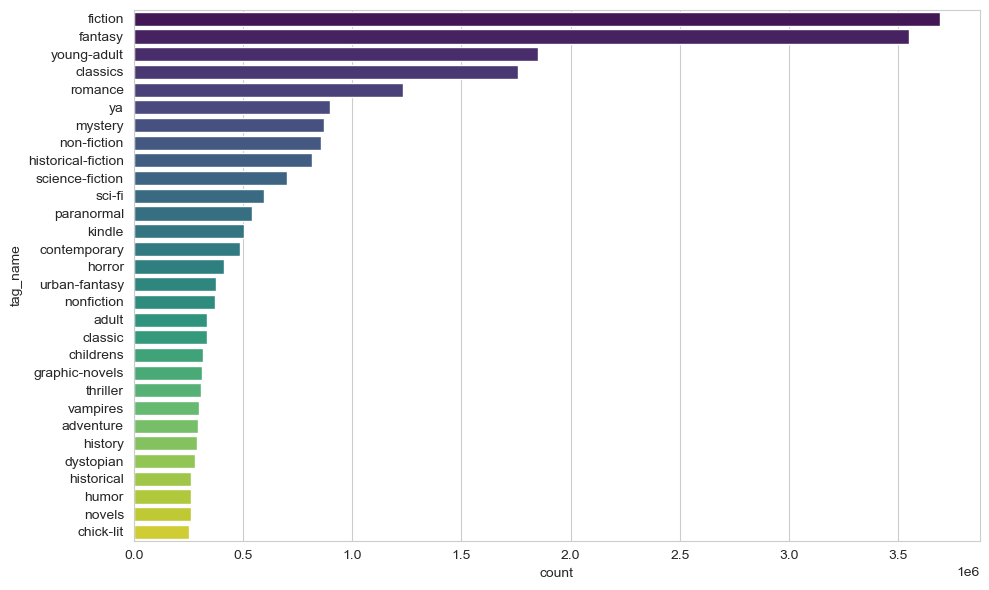

In [23]:
keyword_frequencies = literature_keywords.merge(keywords, on='tag_id', how='inner')

tag_popularity = keyword_frequencies.groupby('tag_name')['count'].sum().reset_index().sort_values('count', ascending=False)

top_tags = tag_popularity.head(30)

# Визуализация популярности топ-30 тегов после глубокой очистки
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

palette = sns.color_palette("viridis", len(top_tags))
ax = sns.barplot(
    y='tag_name',
    x='count',
    data=top_tags,
    hue='tag_name',  
    palette=palette,
    legend=False 
)

plt.tight_layout()
plt.show()

**Шумные теги минимизированы (не в топ-30), при необходимости вернемся к дополнительной фильтрации**

## 2. Базовые и контент-ориентированные модели

In [24]:
### Модель на основе популярности
def compute_book_statistics(ratings_df):
    return ratings_df.groupby('book_id')['rating'].agg(['mean', 'count']).reset_index().rename(columns={'mean': 'avg_rating', 'count': 'rating_count'})

# Вычисление статистики
book_stats = compute_book_statistics(user_reviews)

top_books = book_stats[book_stats['rating_count'] >= 20].sort_values('avg_rating', ascending=False).head(10)

# Merge с literature: используем правильные ключи для корректного слияния
merged = pd.merge(
    top_books,
    literature[['id', 'original_title']],  
    left_on='book_id',  
    right_on='id',     
    how='left'
)

# Заполняем NaN в original_title
merged['original_title'] = merged['original_title'].fillna('Unknown')
    
merged

,book_id,avg_rating,rating_count,id,original_title
0,7947,4.820225,89,7947,ESV Study Bible
1,6920,4.780000,100,6920,The Indispensable Calvin and Hobbes: A Calvin and Hobbes Treasury
2,5207,4.780000,100,5207,The Days Are Just Packed: A Calvin and Hobbes Collection
3,9566,4.777778,99,9566,Attack of the Deranged Mutant Killer Monster Snow Goons: A Calvin and Hobbes Collection
4,8946,4.774194,93,8946,دیوان‎‎ [Dīvān]
5,3275,4.770000,100,3275,"Harry Potter Boxed Set, Books 1-5 (Harry Potter, #1-5)"
6,6361,4.770000,100,6361,There's Treasure Everywhere: A Calvin and Hobbes Collection
7,4483,4.750000,100,4483,It's a Magical World: A Calvin and Hobbes Collection
8,6590,4.750000,100,6590,The Authoritative Calvin and Hobbes
9,5580,4.750000,100,5580,The Calvin and Hobbes Lazy Sunday Book


**Контент-ориентированная модель**

In [25]:
literature_for_merge = literature[['book_id', 'original_title']
books_tags_merged = literature_keywords.merge(
    literature_for_merge, 
    left_on='goodreads_book_id', 
    right_on='book_id',  
    how='inner'
).merge(
    keywords[['tag_id', 'tag_name']], 
    left_on='tag_id', 
    right_on='tag_id', 
    how='inner'
)

# Профили тегов
tag_profiles = books_tags_merged.groupby('book_id')['tag_name'].apply(
    lambda tags_list: ' '.join(sorted(list(set(tags_list))))
).reset_index()
tag_profiles.columns = ['book_id', 'tag_summary']

# Профили книг
complete_profiles = literature[['book_id', 'original_title']].merge(
    tag_profiles, 
    on='book_id',  # 'book_id' как Goodreads ID для сопоставления
    how='left'
)
complete_profiles['tag_summary'] = complete_profiles['tag_summary'].fillna('')
complete_profiles['search_text'] = (
    complete_profiles['original_title'].fillna('') + ' ' + complete_profiles['tag_summary']
).str.lower().str.strip()

# Фильтр
complete_profiles = complete_profiles[complete_profiles['tag_summary'] != ''].copy()
print(f"Количество профилей с тегами: {len(complete_profiles)}")

# Векторизация TF-IDF для семантического представления текстов
vectorizer = TfidfVectorizer(
    max_features=15000, 
    stop_words='english', 
    ngram_range=(1, 3) 
)
text_vectors = vectorizer.fit_transform(complete_profiles['search_text'])

# Индексные словари для эффективного поиска (двунаправленные)
id_to_index = dict(zip(complete_profiles['book_id'], range(len(complete_profiles))))
index_to_id = {idx: book_id for book_id, idx in id_to_index.items()}

def get_recommendations(target_id, num_recs=5, with_metadata=True):
    """
    Находит похожие книги на основе TF-IDF cosine similarity.
    Возвращает список рекомендаций (с деталями или только названиями).
    target_id ожидается как Goodreads book_id (из literature['book_id']).
    """
    if target_id not in id_to_index:
        print(f"Книга с ID {target_id} не найдена в профилях (проверьте наличие тегов).")
        return []
    
    source_index = id_to_index[target_id]
    sim_scores = cosine_similarity(text_vectors[source_index:source_index+1], text_vectors).flatten()
    ranked_indices = sim_scores.argsort()[::-1]
    
    recommendations = []
    for pos in ranked_indices[1:]:  # Пропускаем [0] - это сама книга
        if len(recommendations) >= num_recs:
            break
        cand_id = complete_profiles.iloc[pos]['book_id']
        cand_title = complete_profiles.iloc[pos]['original_title']
        sim_value = sim_scores[pos]
        rec_item = {'id': cand_id, 'name': cand_title, 'match_score': sim_value}
        recommendations.append(rec_item)
    
    book_name = complete_profiles.loc[complete_profiles['book_id'] == target_id, 'original_title'].iloc[0]
    print(f'Рекомендации для "{book_name}":')
    if with_metadata:
        rec_df = pd.DataFrame(recommendations)
        print(rec_df.to_string(index=False))  #
        return recommendations
    else:
        titles_only = [item['name'] for item in recommendations]
        for title in titles_only:
            print(f'- {title}')
        return titles_only

# Демонстрация
if len(complete_profiles) > 8:
    sample_id = complete_profiles['book_id'].iloc[8]
    get_recommendations(sample_id, num_recs=5)
else:
    print("Недостаточно профилей с тегами для демонстрации. Проверьте overlaps в проверках выше.")
    # Альтернатива: рекомендации для первой доступной
    if len(complete_profiles) > 0:
        sample_id = complete_profiles['book_id'].iloc[0]
        get_recommendations(sample_id, num_recs=5)

Количество профилей с тегами: 10000
Рекомендации для "Angels & Demons ":
      id              name  match_score
     968 The Da Vinci Code     0.724010
   11125  Digital Fortress     0.664042
 6411961   The Lost Symbol     0.655661
     976   Deception Point     0.636028
17212231           Inferno     0.627119


## 3. Коллаборативная фильтрация

In [39]:
def retrieve_most_popular_titles(count, feedback_data):
    # Собираем данные по идентификаторам произведений, подсчитывая отзывы
    title_tally = feedback_data.groupby('book_id').size().reset_index(name='tally')
    # Упорядочиваем по количеству и выбираем первые N
    leading_titles = title_tally.sort_values('tally', ascending=False).head(count)
    # Возвращаем список идентификаторов как целые числа
    return leading_titles['book_id'].astype(int).tolist()

# Улучшенный метод создания разреженной матрицы пользователь-произведение
def construct_sparse_representation(dataframe):
    # Верификация присутствия обязательных колонок
    essential_columns = ['user_id', 'book_id', 'rating']
    for column in essential_columns:
        if column not in dataframe.columns:
            raise ValueError(f"Колонка '{column}' не найдена в dataframe.")
    
    unique_users = dataframe['user_id'].unique()
    unique_books = dataframe['book_id'].unique()
    user_to_index = {usr: idx for idx, usr in enumerate(unique_users)}
    book_to_index = {bk: idx for idx, bk in enumerate(unique_books)}
    row_indices = dataframe['user_id'].map(user_to_index)
    col_indices = dataframe['book_id'].map(book_to_index)
    values = dataframe['rating'].astype(float)
    interaction_matrix = csr_matrix((values, (row_indices, col_indices)), shape=(len(unique_users), len(unique_books)))
    return interaction_matrix, user_to_index, book_to_index, unique_users, unique_books

# Метод прогнозирования оценки с использованием item-based CF (усовершенствован для производительности)
def estimate_rating_via_items(interaction_matrix, user_map, book_map, target_user, target_book, similarity_count=20, overall_average=None):
    
    if overall_average is None:
        overall_average = user_reviews['rating'].mean()
    
    # Проверяем наличие пользователя и книги
    if target_user not in user_map or target_book not in book_map:
        return overall_average
    
    # Преобразуем и стандартизируем для вычисления сходства между произведениями
    item_user_matrix = interaction_matrix.T.tocsr()
    normalized_item_matrix = normalize(item_user_matrix, axis=1)
    user_index = user_map[target_user]
    book_index = book_map[target_book]
    
    # Определяем сходство целевого произведения с остальными
    similarities = normalized_item_matrix.dot(normalized_item_matrix[book_index].T).toarray().ravel()
    rated_books_indices = interaction_matrix[user_index].nonzero()[1]  
    
    if len(rated_books_indices) == 0:
        return overall_average
    
    # Выбираем top-K наиболее похожих оцененных произведений
    relevant_similarities = [(idx, similarities[idx]) for idx in rated_books_indices if similarities[idx] > 0] 
    relevant_similarities = sorted(relevant_similarities, key=lambda pair: pair[1], reverse=True)[:similarity_count]
    
    if not relevant_similarities:  #
        return overall_average
    
    # Прогноз на основе взвешенного среднего
    numerator = sum(sim * interaction_matrix[user_index, idx] for idx, sim in relevant_similarities)
    denominator = sum(abs(sim) for _, sim in relevant_similarities)
    return float(numerator / denominator) if denominator > 0 else overall_average


def generate_item_based_suggestions(interaction_matrix, user_map, book_map, user_list, book_list, target_user, top_count=10, similarity_count=20, feedback_data=None):
    # Резервный вариант: популярные произведения
    if target_user not in user_map:
        return retrieve_most_popular_titles(top_count, feedback_data if feedback_data is not None else user_reviews)
    
    user_index = user_map[target_user]
    rated_books_indices = interaction_matrix[user_index].nonzero()[1]
    
    # Резервный вариант, если пользователь не оценивал ничего
    if len(rated_books_indices) == 0:
        return retrieve_most_popular_titles(top_count, feedback_data if feedback_data is not None else user_reviews)
    
    # Суммируем сходства для неоцененных произведений
    normalized_item_matrix = normalize(interaction_matrix.T.tocsr(), axis=1)
    cumulative_similarity = np.zeros(len(book_list))
    
    for rated_index in rated_books_indices:
        similarities = normalized_item_matrix.dot(normalized_item_matrix[rated_index].T).toarray().ravel()
        cumulative_similarity += similarities
    
    cumulative_similarity /= len(rated_books_indices)  # Среднее сходство
    
    # Ранжируем и отсеиваем уже оцененные
    sorted_indices = np.argsort(cumulative_similarity)[::-1]
    seen_books = {book_list[idx] for idx in rated_books_indices}
    suggestions = [int(book_list[idx]) for idx in sorted_indices if book_list[idx] not in seen_books][:top_count]
    
    return suggestions

# Демонстрация применения (адаптирована под предоставленные данные)
interaction_matrix, user_map, book_map, user_list, book_list = construct_sparse_representation(user_reviews)
overall_average = user_reviews['rating'].mean()

print(f'Прогнозируемая оценка пользователя 12 для произведения 5: {estimate_rating_via_items(interaction_matrix, user_map, book_map, target_user=100, target_book=66, overall_average=overall_average):.2f}')
print('Предлагаемые произведения:', generate_item_based_suggestions(interaction_matrix, user_map, book_map, user_list, book_list, target_user=100, top_count=5, feedback_data=user_reviews))

Прогнозируемая оценка пользователя 12 для произведения 5: 5.00
Предлагаемые произведения: [9858, 8336, 8882, 9473, 7639]
